# PR #702 `_r.dat` on the SrTiO3 symmetry-forced zeros

PR #702 gives `wannier90.x` the translation-equivariant position matrix under `transl_inv_full=T`. Verified separately (`validation/inputs/compare_pr702_rdat.ipynb`): the file it writes is postw90's `get_AA_R` at `use_ws_distance=F`, to 4.4e-16. This notebook answers whether that matrix is *usable* -- which file-level agreement cannot say, because `plot_write_rmn` runs before any Wigner-Seitz mapping exists and so can only ever emit the `use_ws_distance=F` representative.

Each supplied `_r.dat` is pushed through the same `rdat_pair` / `rdat_direct` pipelines and compared against `mmn_pair` and `rfull_pair` (postw90 at `use_ws_distance=T`). Supplying both a `6F12.6` and an `ES24.16E3` build of the same run separates the print format from the representative choice.

Set `RUN_COMPUTATION = False` to load the last saved curves from `results/pr702_rdat_symmetry/` -- the summary table and figures are always rebuilt from whatever `curves`/`t` end up in memory, computed or loaded, mirroring the original script's `--plot-only` mode.

In [1]:
import csv
import shutil
import sys
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "validation").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from validation._paths import RESULTS
import validation.symmetry.check_convention_symmetry_lib as ccs

## Config

In [2]:
RUN_COMPUTATION = False  # True: rebuild curves via ccs.calculate. False: load results/pr702_rdat_symmetry/.
N_POINTS = 201
OUTPUT_DIR = RESULTS / "pr702_rdat_symmetry"
# Each entry: (name, base_r_dat_path, mode_r_dat_path) -- a _r.dat pair to score, e.g.
# a PR #702 build to compare against the stock mmn_pair/rfull_pair/rdat_pair/rdat_direct curves.
VARIANTS = []

#: notes/log/2026-08-27_rfull_vs_mmn_position_matrix.md, set (c), .mmn route.
BASELINE = {
    ("base", "generic"): 8.6e-09,
    ("base", "mirror_kx_half"): 4.4e-09,
    ("mode", "mirror_kx_half"): 8.1e-08,
}
ZEROS = [
    ("base", "generic", "base generic (P+T)"),
    ("base", "mirror_kx_half", "base kx=1/2 mirror"),
    ("mode", "mirror_kx_half", "mode kx=1/2 mirror"),
]
PREFIX = "SrTiO3"

## Helpers: numpy/tensorflow fallback, scratch-directory mirroring

In [3]:
def mirror(run_directory: Path, replacement_rdat: Path, destination: Path) -> Path:
    """Symlink a run, substituting only ``PREFIX_r.dat``."""
    destination.mkdir(parents=True, exist_ok=True)
    for entry in run_directory.iterdir():
        link = destination / entry.name
        if not link.exists():
            link.symlink_to(entry)
    target = destination / f"{PREFIX}_r.dat"
    if target.exists() or target.is_symlink():
        target.unlink()
    target.symlink_to(replacement_rdat.resolve())
    return destination


def collect(ccs, tag, conventions, n_points, base=None, mode=None):
    original = (ccs.TRIALS["c"]["base"], ccs.TRIALS["c"]["mode"])
    if base is not None:
        ccs.TRIALS["c"]["base"], ccs.TRIALS["c"]["mode"] = base, mode
    try:
        _, _, curves, _ = ccs.calculate(n_points, ["c"], conventions)
    finally:
        ccs.TRIALS["c"]["base"], ccs.TRIALS["c"]["mode"] = original
    out = {}
    for convention in conventions:
        name = f"{convention} [{tag}]" if tag else convention
        for structure, path, _ in ZEROS:
            key = ("c", structure, convention, path)
            if key in curves:
                out[(name, structure, path)] = np.asarray(curves[key])
    return out

## Helpers: save/load, tables

In [4]:
def pipeline_order(names) -> list[str]:
    """References first, then each _r.dat pipeline stock -> variants."""
    return sorted(set(names), key=lambda n: (
        not n.startswith(("mmn", "rfull")),
        n.split(" [")[0] != "rdat_pair",
        "[stock]" not in n,
        n,
    ))


def save_curves(output_dir: Path, t: np.ndarray, curves: dict) -> Path:
    output_dir.mkdir(parents=True, exist_ok=True)
    arrays = {"t": t}
    arrays.update({"|".join(key): values for key, values in curves.items()})
    path = output_dir / "symmetry_curves.npz"
    np.savez_compressed(path, **arrays)
    return path


def load_curves(output_dir: Path) -> tuple[np.ndarray, dict]:
    with np.load(output_dir / "symmetry_curves.npz") as data:
        t = data["t"]
        curves = {tuple(k.split("|")): data[k] for k in data.files if k != "t"}
    return t, curves


def times(ratio: float) -> str:
    """3 significant figures, comma-grouped: 318,000x rather than 3.18e+05x."""
    return f"{float(f'{ratio:.3g}'):,.0f}x" if ratio >= 1000 else f"{ratio:.3g}x"


def write_tables(output_dir: Path, maxima: dict) -> list[Path]:
    """Max |Tr Omega_xy| per pipeline and zero, absolute and relative to .mmn."""
    names = pipeline_order(k[0] for k in maxima)
    csv_path = output_dir / "max_trace_omega.csv"
    with csv_path.open("w", newline="") as stream:
        writer = csv.writer(stream)
        writer.writerow(["pipeline", "structure", "path", "zero",
                         "max_abs_trace_omega_xy_A2", "ratio_to_mmn_pair"])
        for name in names:
            for structure, path, label in ZEROS:
                value = maxima.get((name, structure, path))
                if value is None:
                    continue
                ratio = value / maxima[("mmn_pair", structure, path)]
                writer.writerow([name, structure, path, label,
                                 f"{value:.6e}", f"{ratio:.6e}"])

    md_path = output_dir / "max_trace_omega.md"
    lines = [
        "max |Tr Omega_xy| on symmetry-forced zeros, SrTiO3 set (c), "
        "48 WF / 38 occupied  [A^2]; (x .mmn) in brackets",
        "",
        "| pipeline | " + " | ".join(label for _, _, label in ZEROS) + " |",
        "|---|" + "---|" * len(ZEROS),
    ]
    for name in names:
        cells = []
        for structure, path, _ in ZEROS:
            value = maxima.get((name, structure, path))
            if value is None:
                cells.append("--")
                continue
            ratio = value / maxima[("mmn_pair", structure, path)]
            cells.append(f"{value:.3e} ({times(ratio)})")
        lines.append(f"| `{name}` | " + " | ".join(cells) + " |")
    md_path.write_text("\n".join(lines) + "\n")
    return [csv_path, md_path]

## Helpers: figures

In [5]:
#: Colours follow the entity across every PR #702 figure (dataviz reference
#: palette, slots 1-5; adjacent pairs validated, and the pairs that overlap on
#: the plot -- the two references, the two PR #702 builds -- are adjacent).
#: Contrast of slots 3-5 is below 3:1, so the table is the required twin.
SERIES = {
    "mmn_pair": ("#2a78d6", "-", ".mmn route (ours)"),
    "rfull_pair": ("#eb6834", (0, (5, 2)), "postw90 write_aa_r _r_full.dat, ws=T (ours)"),
    "stock": ("#1baf7a", "-", "stock _r.dat"),
    "PR702": ("#eda100", "-", "PR #702 _r.dat, 6F12.6"),
    "PR702hp": ("#e87ba4", (0, (5, 2)), "PR #702 _r.dat, ES24.16E3"),
}
INK, INK_SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE, GRID, AXIS = "#fcfcfb", "#e1e0d9", "#c3c2b7"


def series_of(pipeline: str) -> str | None:
    if pipeline in ("mmn_pair", "rfull_pair"):
        return pipeline
    if "[stock]" in pipeline:
        return "stock"
    if "ES24" in pipeline:
        return "PR702hp"
    if "6F12" in pipeline or "PR" in pipeline:
        return "PR702"
    return None


def _style_axis(ax) -> None:
    ax.set_facecolor(SURFACE)
    ax.grid(True, which="major", color=GRID, linewidth=0.6, linestyle="-")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
        ax.spines[side].set_linewidth(0.8)
    ax.tick_params(colors=MUTED, labelcolor=INK_SECONDARY, labelsize=8)


def plot(output_dir: Path, t: np.ndarray, curves: dict) -> list[Path]:
    plt.rcParams.update({"font.family": "sans-serif", "text.color": INK,
                         "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK})
    floor = 1e-12
    names = pipeline_order(k[0] for k in curves)
    maxima = {key: float(np.abs(values).max()) for key, values in curves.items()}
    saved = []

    fig, axes = plt.subplots(1, len(ZEROS), figsize=(13.5, 3.9), dpi=180,
                             sharey=True, facecolor=SURFACE)
    shown = [n for n in names if not n.startswith("rdat_direct") and series_of(n)]
    for ax, (structure, path, title) in zip(axes, ZEROS):
        _style_axis(ax)
        for name in shown:
            values = curves.get((name, structure, path))
            if values is None:
                continue
            color, dash, label = SERIES[series_of(name)]
            ax.plot(t, np.clip(np.abs(values), floor, None), color=color,
                    linestyle=dash, linewidth=1.6, label=label,
                    solid_capstyle="round", solid_joinstyle="round")
        ax.set_yscale("log")
        ax.set_ylim(floor, 1e-1)
        ax.set_xlim(0, 1)
        ax.set_title(title, loc="left", fontsize=9.5)
        ax.set_xlabel("path parameter $t$")
    axes[0].set_ylabel(r"$|{\rm Tr}\,\Omega_{xy}|$ [$\AA^2$]  (should be 0)")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False,
               fontsize=8.5, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Symmetry-forced zeros of Tr $\\Omega_{xy}$ through the in-house "
                 "_r.dat + use_ws_distance pipeline (rdat_pair) -- SrTiO$_3$ set (c), "
                 "48 WF / 38 occupied", x=0.01, ha="left", fontsize=10.5)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    path = output_dir / "pr702_symmetry_curves.png"
    fig.savefig(path, bbox_inches="tight", facecolor=SURFACE)
    saved.append(path)

    fig, axes = plt.subplots(1, len(ZEROS), figsize=(13.5, 0.42 * len(names) + 1.4),
                             dpi=180, sharey=True, facecolor=SURFACE)
    rows = np.arange(len(names))[::-1]
    for ax, (structure, path, title) in zip(axes, ZEROS):
        _style_axis(ax)
        ax.grid(False, axis="y")
        reference = maxima[("mmn_pair", structure, path)]
        for y, name in zip(rows, names):
            value = maxima.get((name, structure, path))
            key = series_of(name)
            if value is None or key is None:
                continue
            color = SERIES[key][0]
            hollow = name.startswith("rdat_direct")
            ax.plot([reference, value], [y, y], color=GRID, linewidth=1.0, zorder=1)
            ax.plot(value, y, "o", markersize=7, zorder=3,
                    markerfacecolor=SURFACE if hollow else color,
                    markeredgecolor=color if hollow else SURFACE,
                    markeredgewidth=1.8 if hollow else 1.2)
            if key == "PR702" and name.startswith("rdat_pair"):
                ax.annotate(f"{times(value / reference)} .mmn", (value, y),
                            xytext=(0, 7), textcoords="offset points", ha="center",
                            fontsize=7.5, color=INK_SECONDARY)
        ax.axvline(reference, color=AXIS, linewidth=0.8, zorder=0)
        ax.set_xscale("log")
        ax.set_xlim(1e-9, 2e-1)
        ax.set_title(title, loc="left", fontsize=9.5)
        ax.set_xlabel(r"max $|{\rm Tr}\,\Omega_{xy}|$ over the path [$\AA^2$]")
    axes[0].set_yticks(rows)
    axes[0].set_yticklabels(names, fontsize=8)
    axes[0].set_ylim(-0.7, len(names) - 0.3)
    legend = [Line2D([], [], marker="o", linestyle="", markersize=7,
                     markerfacecolor=color, markeredgecolor=SURFACE, label=label)
              for color, _, label in SERIES.values()]
    legend.append(Line2D([], [], marker="o", linestyle="", markersize=7,
                         markerfacecolor=SURFACE, markeredgecolor=MUTED,
                         markeredgewidth=1.8, label="hollow: rdat_direct (no remap)"))
    fig.legend(handles=legend, loc="lower center", ncol=3, frameon=False, fontsize=8.5,
               bbox_to_anchor=(0.5, 0.0))
    fig.suptitle("Worst symmetry violation per pipeline -- vertical rule = .mmn route; "
                 "SrTiO$_3$ set (c)", x=0.01, ha="left", fontsize=10.5)
    fig.tight_layout(rect=(0, 0.13, 1, 1))
    path = output_dir / "pr702_symmetry_maxima.png"
    fig.savefig(path, bbox_inches="tight", facecolor=SURFACE)
    saved.append(path)
    return saved

## Compute: stock curves + baseline check + any variants

`curves[(pipeline_name, structure, path)]` is the Tr Omega_xy array along that path -- inspect any entry directly.

In [6]:
if RUN_COMPUTATION:
    t = np.linspace(0.0, 1.0, N_POINTS)
    curves = collect(ccs, "stock", ["mmn_pair", "rfull_pair", "rdat_pair", "rdat_direct"], N_POINTS)
    curves = {(k[0].replace("mmn_pair [stock]", "mmn_pair")
                   .replace("rfull_pair [stock]", "rfull_pair"), k[1], k[2]): v
              for k, v in curves.items()}

    failures = []
    for (s, p), want in BASELINE.items():
        got = float(np.abs(curves[("mmn_pair", s, p)]).max())
        if not 0.2 < got / want < 5:
            failures.append(f"{s}/{p}: got {got:.3e}, recorded {want:.1e}")
    if failures:
        raise RuntimeError("BASELINE CHECK FAILED -- downstream numbers are not trustworthy:\n"
                           + "\n".join("  " + f for f in failures))

c/base/mmn_pair


    SrTiO3.mmn absent; reusing AA_symmetry_c_base_185116bc889_wbnone_ws1em05.npz on its recorded provenance (staleness of the deleted input cannot be re-verified)


c/mode/mmn_pair


    SrTiO3.mmn absent; reusing AA_symmetry_c_mode_185119bc889_wbnone_ws1em05.npz on its recorded provenance (staleness of the deleted input cannot be re-verified)


c/base/rfull_pair


c/mode/rfull_pair


c/base/rdat_pair


c/mode/rdat_pair


c/base/rdat_direct


c/mode/rdat_direct


In [7]:
if RUN_COMPUTATION and VARIANTS:
    scratch = Path(tempfile.mkdtemp(prefix="pr702_sym_"))
    try:
        for index, (name, base_rdat, mode_rdat) in enumerate(VARIANTS):
            base_dir = mirror(Path(ccs.TRIALS["c"]["base"]), Path(base_rdat),
                              scratch / str(index) / "base")
            mode_dir = mirror(Path(ccs.TRIALS["c"]["mode"]), Path(mode_rdat),
                              scratch / str(index) / "mode")
            curves.update(collect(ccs, name, ["rdat_pair", "rdat_direct"],
                                  N_POINTS, base_dir, mode_dir))
    finally:
        shutil.rmtree(scratch, ignore_errors=True)

## Save

In [8]:
if RUN_COMPUTATION:
    print(f"saved {save_curves(OUTPUT_DIR, t, curves)}")

saved /Users/treycole/Repos/axion-phonon/validation/results/pr702_rdat_symmetry/symmetry_curves.npz


## Load previously saved curves (skip if you just computed above)

In [9]:
if not RUN_COMPUTATION:
    t, curves = load_curves(OUTPUT_DIR)

## Summary table + figures

Always rebuilt from whatever `curves`/`t` are in memory (computed or loaded), mirroring the original script's `--plot-only` mode -- cheap, and keeps the saved table/figures in sync with whichever curves you just inspected.

In [10]:
maxima = {key: float(np.abs(values).max()) for key, values in curves.items()}

print("max |Tr Omega_xy| on symmetry-forced zeros -- SrTiO3 set (c)  [A^2]\n")
header = f"{'pipeline':32s}" + "".join(f"{d:>22s}" for _, _, d in ZEROS)
print(header)
print("-" * len(header))
for name in pipeline_order(k[0] for k in maxima):
    row = f"{name:32s}"
    for structure, path, _ in ZEROS:
        value = maxima.get((name, structure, path))
        row += f"{'--' if value is None else f'{value:.3e}':>22s}"
    print(row)

max |Tr Omega_xy| on symmetry-forced zeros -- SrTiO3 set (c)  [A^2]

pipeline                            base generic (P+T)    base kx=1/2 mirror    mode kx=1/2 mirror
--------------------------------------------------------------------------------------------------
mmn_pair                                     7.306e-09             3.700e-09             8.030e-08
rfull_pair                                   1.230e-09             8.105e-10             7.934e-08
rdat_pair [stock]                            3.971e-02             1.651e-02             1.653e-02
rdat_direct [stock]                          4.057e-02             1.911e-02             1.922e-02


saved /Users/treycole/Repos/axion-phonon/validation/results/pr702_rdat_symmetry/max_trace_omega.csv
saved /Users/treycole/Repos/axion-phonon/validation/results/pr702_rdat_symmetry/max_trace_omega.md


saved /Users/treycole/Repos/axion-phonon/validation/results/pr702_rdat_symmetry/pr702_symmetry_curves.png
saved /Users/treycole/Repos/axion-phonon/validation/results/pr702_rdat_symmetry/pr702_symmetry_maxima.png


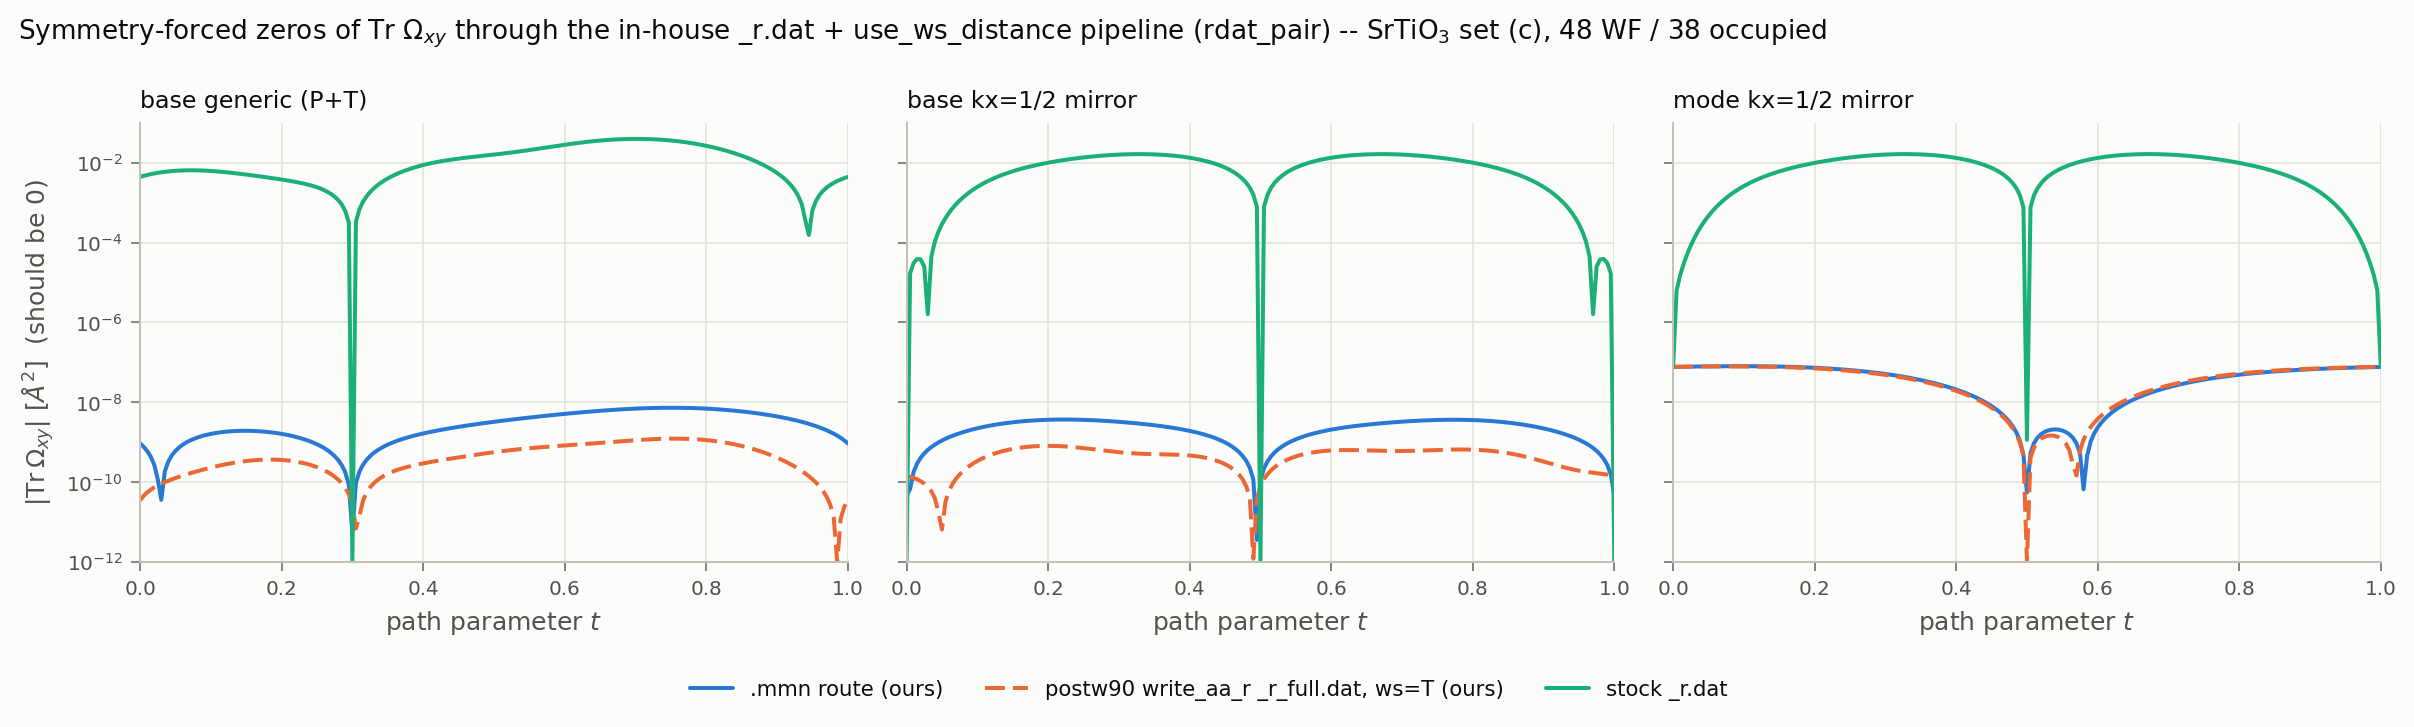

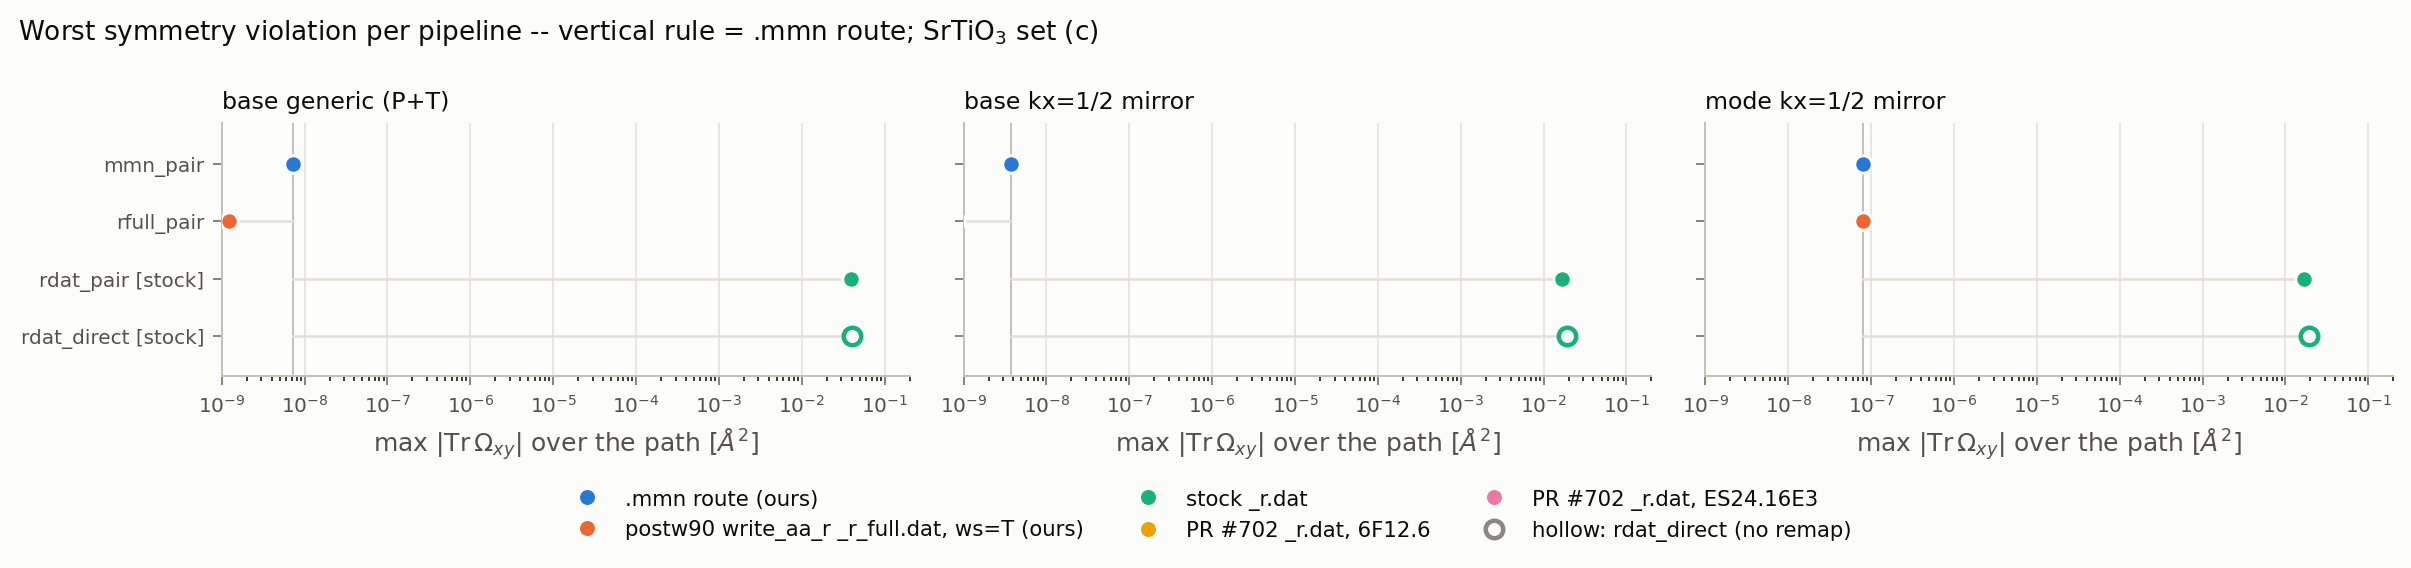

In [11]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for path in write_tables(OUTPUT_DIR, maxima):
    print(f"saved {path}")
for path in plot(OUTPUT_DIR, t, curves):
    print(f"saved {path}")
plt.show()